Number of tokens: 38904 
 ['.', 'sit', 'down', 'awhile', '.', 'and', 'let', 'us', 'once', 'again', 'assail', 'your', 'ears', '.', 'that']
Size of vocabulary: 4482
Most Frequent Tokens: [('.', 7368), ('the', 1085), ('and', 963), ('to', 741), ('of', 675), ('i', 624), ('you', 558), ('a', 557), ('my', 520), ('in', 438), ('it', 419), ('is', 418), ('that', 404), ('ham', 358), ('not', 343), ('his', 304), ('this', 298), ('with', 277), ('but', 273), ('for', 251)]
Size of vocabulary: 4482
Index of the word 'king': 2130
Word which has index 2743: paint
Call gradient_descent
iters: 10 cost: 11.161270
iters: 20 cost: 9.954454
iters: 30 cost: 9.197156
iters: 40 cost: 9.383546
iters: 50 cost: 9.416975
iters: 60 cost: 8.968107
iters: 70 cost: 8.597859
iters: 80 cost: 9.446416
iters: 90 cost: 8.485427
iters: 100 cost: 8.461224
iters: 110 cost: 7.875695
iters: 120 cost: 8.126758
iters: 130 cost: 8.666767
iters: 140 cost: 8.467516
iters: 150 cost: 7.891645
(9, 50) [2130, 3087, 2299, 2352, 4400, 2994, 267

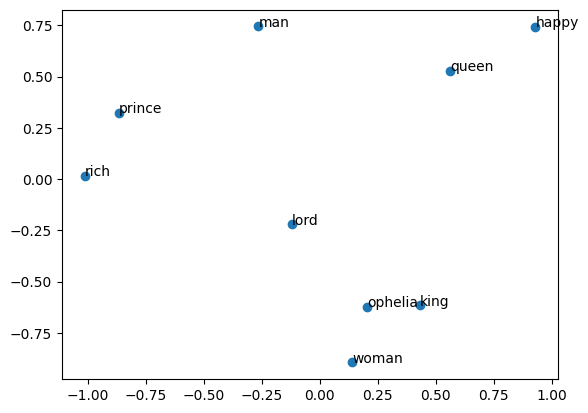

In [4]:
import nltk
import numpy as np
from utils import get_batches
from utils import compute_pca
from utils import get_dict
import re
from matplotlib import pyplot

# Create our corpus for training
with open(r"C:\Users\HADI\Downloads\hamlet.txt", encoding="utf-8") as f:
    data = f.read()

# Slightly clean the data by removing punctuation, tokenizing by word, and converting to lowercase alpha characters
data = re.sub(r"[,!?;-]", ".", data)
data = nltk.word_tokenize(data)
data = [ch.lower() for ch in data if ch.isalpha() or ch == "."]
print("Number of tokens:", len(data), "\n", data[500:515])

# Get our Bag of Words, along with a distribution
fdist = nltk.FreqDist(word for word in data)
print("Size of vocabulary:", len(fdist))
print("Most Frequent Tokens:", fdist.most_common(20))

# Create 2 dictionaries to speed up time-to-convert and keep track of vocabulary
word2Ind, Ind2word = get_dict(data)
V = len(word2Ind)
print("Size of vocabulary:", V)

print("Index of the word 'king':", word2Ind["king"])
print("Word which has index 2743:", Ind2word[2743])


# Here we create our Neural network with 1 layer and 2 parameters
def initialize_model(N, V, random_seed=1):
    """
    Inputs:
        N: dimension of hidden vector
        V: dimension of vocabulary
        random_seed: seed for consistent results in tests
    Outputs:
        W1, W2, b1, b2: initialized weights and biases
    """
    np.random.seed(random_seed)

    W1 = np.random.rand(N, V)
    W2 = np.random.rand(V, N)
    b1 = np.random.rand(N, 1)
    b2 = np.random.rand(V, 1)

    return W1, W2, b1, b2


# Create our final classification layer, which makes all possibilities add up to 1
def softmax(z):
    """
    Inputs:
        z: output scores from the hidden layer
    Outputs:
        yhat: prediction (estimate of y)
    """
    yhat = np.exp(z) / np.sum(np.exp(z), axis=0)
    return yhat


# Define the behavior for moving forward through our model, along with an activation function
def forward_prop(x, W1, W2, b1, b2):
    """
    Inputs:
        x: average one-hot vector for the context
        W1,W2,b1,b2: weights and biases to be learned
    Outputs:
        z: output score vector
    """
    h = W1 @ x + b1
    h = np.maximum(0, h)
    z = W2 @ h + b2
    return z, h


# Define how we determine the distance between ground truth and model predictions
def compute_cost(y, yhat, batch_size):
    logprobs = np.multiply(np.log(yhat), y) + np.multiply(
        np.log(1 - yhat), 1 - y
    )
    cost = -1 / batch_size * np.sum(logprobs)
    cost = np.squeeze(cost)
    return cost


# Define how we move backward through the model and collect gradients
def back_prop(x, yhat, y, h, W1, W2, b1, b2, batch_size):
    """
    Inputs:
        x:  average one hot vector for the context
        yhat: prediction (estimate of y)
        y:  target vector
        h:  hidden vector (see eq. 1)
        W1, W2, b1, b2:  weights and biases
        batch_size: batch size
     Outputs:
        grad_W1, grad_W2, grad_b1, grad_b2:  gradients of weights and biases
    """
    l1 = np.dot(W2.T, yhat - y)
    l1 = np.maximum(0, l1)
    grad_W1 = np.dot(l1, x.T) / batch_size
    grad_W2 = np.dot(yhat - y, h.T) / batch_size
    grad_b1 = np.sum(l1, axis=1, keepdims=True) / batch_size
    grad_b2 = np.sum(yhat - y, axis=1, keepdims=True) / batch_size

    return grad_W1, grad_W2, grad_b1, grad_b2


# Put it all together and train
def gradient_descent(data, word2Ind, N, V, num_iters, alpha=0.03):
    """
    This is the gradient_descent function

      Inputs:
        data:      text
        word2Ind:  words to Indices
        N:         dimension of hidden vector
        V:         dimension of vocabulary
        num_iters: number of iterations
     Outputs:
        W1, W2, b1, b2:  updated matrices and biases

    """
    W1, W2, b1, b2 = initialize_model(N, V, random_seed=8855)
    batch_size = 128
    iters = 0
    C = 2
    for x, y in get_batches(data, word2Ind, V, C, batch_size):
        z, h = forward_prop(x, W1, W2, b1, b2)
        yhat = softmax(z)
        cost = compute_cost(y, yhat, batch_size)
        if (iters + 1) % 10 == 0:
            print(f"iters: {iters+1} cost: {cost:.6f}")
        grad_W1, grad_W2, grad_b1, grad_b2 = back_prop(
            x, yhat, y, h, W1, W2, b1, b2, batch_size
        )
        W1 = W1 - alpha * grad_W1
        W2 = W2 - alpha * grad_W2
        b1 = b1 - alpha * grad_b1
        b2 = b2 - alpha * grad_b2
        iters += 1
        if iters == num_iters:
            break
        if iters % 100 == 0:
            alpha *= 0.66

    return W1, W2, b1, b2


# Train the model
C = 2
N = 50
word2Ind, Ind2word = get_dict(data)
V = len(word2Ind)
num_iters = 150
print("Call gradient_descent")
W1, W2, b1, b2 = gradient_descent(data, word2Ind, N, V, num_iters)

# After listing 2.4 is done and gradient descent has been executed
words = [
    "king",
    "queen",
    "lord",
    "man",
    "woman",
    "prince",
    "ophelia",
    "rich",
    "happy",
]
embs = (W1.T + W2) / 2.0
idx = [word2Ind[word] for word in words]
X = embs[idx, :]
print(X.shape, idx)

result = compute_pca(X, 2)
pyplot.scatter(result[:, 0], result[:, 1])
for i, word in enumerate(words):
    pyplot.annotate(word, xy=(result[i, 0], result[i, 1]))
pyplot.show()